In [1]:
# 1. 필요 라이브러리 설치
!pip install ultralytics

# 2. GitHub 기반 오픈 데이터셋 다운로드 (주사위 탐지 데이터셋)
!git clone https://github.com/Solafune/paddoc-sample-dataset.git datasets-sample
# 혹은 Ultralytics에서 제공하는 공식 경량 데이터셋(Aquarium 등)도 가능하지만, 가장 무난한 포맷으로 자동 생성합니다.

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.7 MB/s eta 0:00:00
Cloning into 'datasets-sample'...
fatal: could not read Username for 'https://github.com': No such device or address


In [2]:
import yaml

# YOLO11 이 인식할 데이터 구조 정의
data_yaml = {
    'train' : '../datasets/coco8/images/train',   # 초경량 8장짜리 coco data
    'val' :  '../datasets/coco8/images/val',
    'nc' : 80,
    'names': ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light']
}

In [3]:
from ultralytics.utils.downloads import download
import zipfile

# 초경량 coco8 데이터셋 다운로드 (실습용 최고)
download('https://ultralytics.com/assets/coco8.zip', unzip=True)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Unzipping /content/coco8.zip to /content/coco8...: 100% ━━━━━━━━━━━━ 25/25 4.3Kfiles/s 0.0s


In [4]:
import os
import shutil
import logging
import numpy as np
import torch
import matplotlib.pyplot as plt
import IPython.display as display
from ultralytics import YOLO
from ultralytics.utils import LOGGER

# 2. 하이퍼파라미터 및 로깅 설정
EPOCH = 10
BATCH_SIZE = 8
LOGGER.propagate = False # 로그 중복 방지


# 3. 가상 data.yaml 파일 생성 (학습 시작 시 자동으로 데이터셋 다운로드 트리거)
with open("data.yaml", "w") as f:
    f.write("""
path: coco8.yaml  # Ultralytics 내장 coco8 처리를 위해 내장 yaml 형식을 빌려옵니다.
train: coco8/images/train
val: coco8/images/val

nc: 80
names: [
  'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light',
  'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
  'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee',
  'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard',
  'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple',
  'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch',
  'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone',
  'microwave', 'over', 'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush'
]
""")

In [12]:
# model = YOLO('yolo11n.pt')
model = YOLO('yolov8n.pt')

In [13]:
# 5. 실시간 손실 그래프용 리스트 초기화
epochs = []
box_losses = []
cls_losses = []
dfl_losses = []

# 6. 에폭 종료 콜백 함수 정의
# trainer : 현재 학습 상태 담고 있는 객체
# >> 현재 에폭 번호, 현재 손실값, 모델 상태

def loss_logger(trainer):
    if hasattr(trainer, "tloss") and trainer.tloss is not None:
        # 손실값 존재 여부 확인 (존재한다면)
        try:
            # 손실값이 tensor 인지 확인
            if isinstance(trainer.tloss, torch.Tensor):
                loss_values = trainer.tloss.tolist()
                # 텐서를 리스트로 변환
            else:
                loss_values = [trainer.tloss]

            # 손실값 분리
            if len(loss_values) >= 3:
                # 3개 이상 존재할 경우
                box_loss, cls_loss, dfl_loss = loss_values[:3]
                # box_loss(객체 위치), cls_loss(객체 종류 잘 맞추었는지), dfl_loss(bbox 경계 정밀하게 예측했는지)
            elif len(loss_values) == 2:
                box_loss, cls_loss = loss_values[:2]
                dfl_loss = 0
            else:
                box_loss = loss_values[0]
                cls_loss, dfl_loss = 0, 0

            display.clear_output(wait=True)
            # 이전 출력 삭제 (현재 출력만 보이)

            epochs.append(trainer.epoch + 1) # 에폭 저장
            box_losses.append(box_loss)
            cls_losses.append(cls_loss)
            dfl_losses.append(dfl_loss)

            print(f'[에폭 {trainer.epoch + 1}] 박스 손실: {box_loss:.3f} | '
                  f'분류 손실: {cls_loss:.3f} | DFL 손실: {dfl_loss:.3f}')

            plt.figure(figsize=(10, 5))
            plt.plot(epochs, box_losses, marker='o', linestyle='-', label='Box Loss', color='b', alpha=0.7)
            plt.plot(epochs, cls_losses, marker='s', linestyle='-', label='Cls Loss', color='g', alpha=0.7)
            plt.plot(epochs, dfl_losses, marker='^', linestyle='-', label='DFL Loss', color='r', alpha=0.7)

            plt.title('YOLO11 Training Loss per Epoch')
            plt.xlabel('Epoch')
            plt.ylabel('Loss Value')
            plt.legend()
            plt.grid(True)
            plt.show()

        except Exception as e:
            print(f"Loss logging error: {e}")

# 6. 콜백 등록(epoch 끝날때 마다 loss_logger() 실행해)
model.add_callback("on_train_epoch_end", loss_logger)

[에폭 10] 박스 손실: 1.139 | 분류 손실: 2.571 | DFL 손실: 1.292


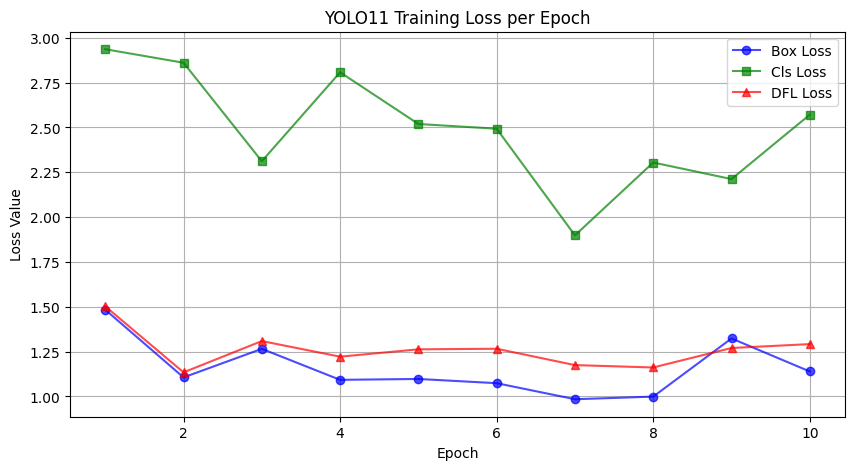

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 10.0it/s 0.1s
                   all          4         17      0.719      0.533      0.607      0.436

10 epochs completed in 0.002 hours.
Optimizer stripped from /content/runs/detect/checkpoints/train/weights/last.pt, 6.5MB
Optimizer stripped from /content/runs/detect/checkpoints/train/weights/best.pt, 6.5MB

Validating /content/runs/detect/checkpoints/train/weights/best.pt...
Ultralytics 8.4.78 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (AMD EPYC 7B12)
Model summary (fused): 73 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 11.3it/s 0.1s
                   all          4         17      0.641      0.633      0.606      0.448
                person          3         10      0.149        0.3      0.158      0.105
                   dog          1          1     

In [14]:
# 7. 모델 학습 시작
results = model.train(
    data='coco8.yaml',
    epochs=EPOCH,
    batch=BATCH_SIZE,
    imgsz=320,
    project='checkpoints', # 결과 저장
    save=True,
    exist_ok=True,
    save_period =5,        # 저장 주기
    plots=False            # yolo 기본 그래프 생성 안함
)